# ============================================================
 FIFA WORLD CUP 2026 - BALL POSSESSION ANALYSIS

 Analytic Question:
 Is there a significant difference in the average
 ball possession percentage between winning and
 losing teams in FIFA World Cup 2026 matches?
# ============================================================

In [1]:
# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Load dataset
# ============================================================

file_path = "FIFA_WC2026_Possession_Final_Sample.csv"
df_sample = pd.read_csv(file_path)

# Check rows and columns of dataset
print("Rows:", df_sample.shape[0])
print("Columns:", df_sample.shape[1])

# View dataset info
print("\n----First 5 rows: ----")
print(df_sample.head())
print("\n")
print(df_sample.info())

Rows: 80
Columns: 5

----First 5 rows: ----
   MatchID                   Match         Team Result  Ball_Possession_pct
0       44       Jordan vs Algeria      Algeria    Win                   72
1        1  Mexico vs South Africa       Mexico    Win                   61
2       33   Netherlands vs Sweden  Netherlands    Win                   51
3       45  Portugal vs Uzbekistan     Portugal    Win                   66
4       29        USA vs Australia          USA    Win                   62


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   MatchID              80 non-null     int64 
 1   Match                80 non-null     object
 2   Team                 80 non-null     object
 3   Result               80 non-null     object
 4   Ball_Possession_pct  80 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 3.3+ KB
Non

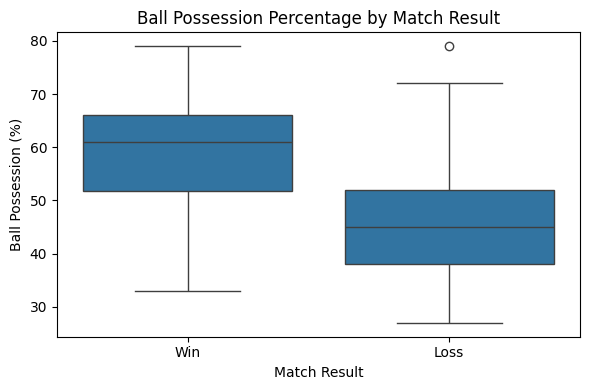

In [3]:
# ============================================================
#  Visualize Ball possession percentage by match result
# ============================================================

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_sample,
    x="Result",
    y="Ball_Possession_pct",
    order=["Win", "Loss"]
)
plt.title("Ball Possession Percentage by Match Result")
plt.xlabel("Match Result")
plt.ylabel("Ball Possession (%)")
plt.tight_layout()
plt.show()

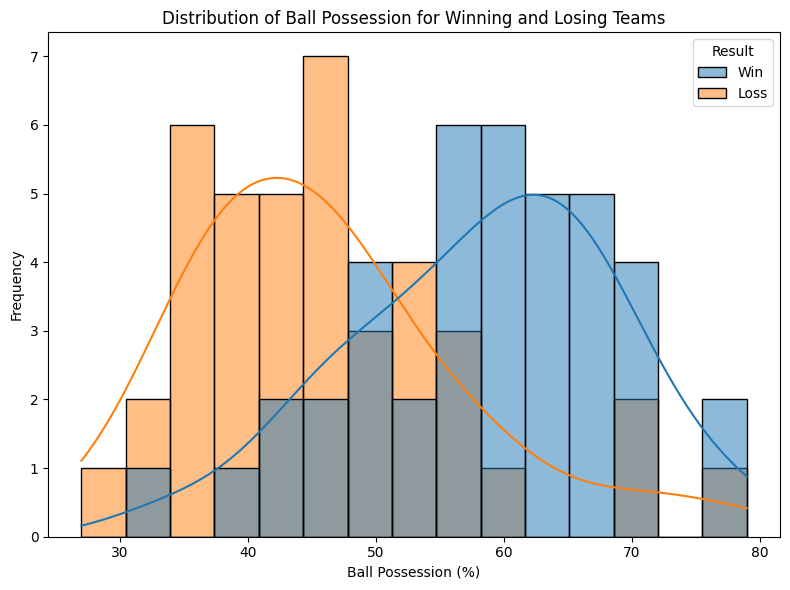

In [4]:
# ============================================================
#  Visualize Distribution of Ball Possession
# ============================================================

# Visualize the distribution of ball possession to assess normality
# for the winning and losing team samples
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df_sample,
    x="Ball_Possession_pct",
    hue="Result",
    kde=True,
    bins=15
)
plt.title("Distribution of Ball Possession for Winning and Losing Teams")
plt.xlabel("Ball Possession (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Separate the sample data into two groups: winning and losing teams
# ============================================================

df_win = df_sample[df_sample["Result"] == "Win"]
df_loss = df_sample[df_sample["Result"] == "Loss"]

print("Winning teams:", len(df_win))
print("Losing teams:", len(df_loss))

Winning teams: 40
Losing teams: 40


In [6]:
# ============================================================
# Descriptive Statistics of sample data
# ============================================================

# Winning teams
winners = df_win["Ball_Possession_pct"]
print("----Statistic of Winning Teams: ----")
print(winners.describe())

# Losing teams
losers = df_loss["Ball_Possession_pct"]
print("\n----Statistic of Losing Teams: ----")
print(losers.describe())

----Statistic of Winning Teams: ----
count    40.000000
mean     58.500000
std      10.355229
min      33.000000
25%      51.750000
50%      61.000000
75%      66.000000
max      79.000000
Name: Ball_Possession_pct, dtype: float64

----Statistic of Losing Teams: ----
count    40.000000
mean     46.050000
std      11.119283
min      27.000000
25%      38.000000
50%      45.000000
75%      52.000000
max      79.000000
Name: Ball_Possession_pct, dtype: float64


In [7]:
# ============================================================
# Descriptive Statistics of sample data (Summary Table)
# ============================================================

summary = pd.DataFrame({
    "Group": ["Winning Teams", "Losing Teams"],
    "N": [len(winners), len(losers)],
    "Mean": [winners.mean(), losers.mean()],
    "Median": [winners.median(), losers.median()],
    "Std_Dev": [winners.std(), losers.std()],
    "Minimum": [winners.min(), losers.min()],
    "Maximum": [winners.max(), losers.max()]
})

print("----Summary table: ----")
print(summary.round(2))

# Mean difference
mean_diff = winners.mean() - losers.mean()

print("\n----Mean Difference: -----")
print(f"Winners - Losers = {mean_diff:.2f} percentage points")

----Summary table: ----
           Group   N   Mean  Median  Std_Dev  Minimum  Maximum
0  Winning Teams  40  58.50    61.0    10.36       33       79
1   Losing Teams  40  46.05    45.0    11.12       27       79

----Mean Difference: -----
Winners - Losers = 12.45 percentage points
